### **PARTE 1.1 -- Instalación de librerías necesarias**

En esta celda se instalan las librerías necesarias para el proyecto:  

- **`networkx`**: Una librería de Python para crear, manipular y analizar grafos y redes complejas.  
- **`pyngrok`**: Una herramienta que permite exponer localmente servicios web o aplicaciones a través de un túnel de Internet utilizando la plataforma Ngrok.  

Este paso asegura que las dependencias estén listas para el análisis y la conexión de la aplicación.


In [1]:
!pip install networkx
!pip install pyngrok

### **PARTE 1.2 -- Configuración del token de autenticación para Ngrok**

En esta celda se configura **Ngrok** añadiendo el token de autenticación mediante el comando:  
`!ngrok config add-authtoken`.  

Este token es necesario para autenticar al usuario y habilitar el acceso a las funcionalidades avanzadas de **Ngrok**, como la creación de túneles seguros. Asegúrate de reemplazar `<AUTHTOKEN>` con tu token personal proporcionado por la cuenta de Ngrok.  


In [2]:
!ngrok config add-authtoken 2rSSPQVUdYuvR2re3xBonxlaufZ_3K6UKUNTwpqgg1hjk6KTi

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


### **PARTE 2 -- Importación de librerías esenciales**

En esta celda se importan las librerías clave que serán utilizadas en el proyecto:  

- **`queue`**: Proporciona estructuras de datos tipo cola para manejar tareas encoladas de manera eficiente.  
- **`networkx`**: Se utiliza para la creación y manipulación de grafos.  
- **`Flask`**: Framework para construir aplicaciones web ligeras en Python. Se importan funciones específicas como `Flask`, `render_template_string`, y `request`.  
- **`pyngrok`**: Para manejar túneles Ngrok desde Python.  
- **`threading`**: Permite la ejecución de tareas en paralelo utilizando hilos.  
- **`random`**: Para generar valores aleatorios, útil para simulaciones o asignaciones aleatorias en el código.  
- **`matplotlib.pyplot`**: Librería para la generación de gráficos y visualizaciones.  

Estas librerías proporcionan la base para crear y visualizar grafos, desarrollar una interfaz web interactiva y exponerla a través de Internet.


In [3]:
import queue
import networkx as nx
from flask import Flask, render_template_string, request
from pyngrok import ngrok
import threading
import random
import matplotlib.pyplot as plt

### **PARTE 3 -- Creación y visualización del grafo de Madrid**

En esta celda se define la clase **`MadridGraph`** y se implementan funciones clave para crear y analizar un grafo que representa la ciudad de Madrid, considerando nodos, aristas, zonas especiales y factores externos:  

1. **Estructura del grafo**:  
   - Utiliza **`networkx`** para modelar la ciudad como un grafo no dirigido donde:  
     - Los nodos representan lugares (ej. "Castellana", "Retiro").  
     - Las aristas representan conexiones entre lugares, con pesos que indican el tiempo de viaje en minutos.  

2. **Características del grafo**:  
   - **Zonas prohibidas**: Lugares restringidos para el dron (ej. "Aeropuerto").  
   - **Condiciones climáticas**: Factores como viento o lluvia que ralentizan el dron.  
   - **Obstáculos**: Lugares con estructuras que afectan la navegación del dron.  

3. **Funciones principales**:  
   - `add_nodes_and_edges`: Agrega nodos y aristas con sus respectivos pesos.  
   - `get_neighbors`: Devuelve los nodos conectados a un nodo específico.  
   - `get_distance`: Obtiene la distancia (peso) entre dos nodos.  
   - `get_weather_factor` y `get_obstacle_factor`: Introducen factores aleatorios que simulan las condiciones climáticas y obstáculos.  
   - `is_prohibited_zone`: Verifica si un nodo es una zona prohibida.  

4. **Visualización del grafo**:  
   - La función **`draw_graph`** dibuja el grafo con posiciones predefinidas y colores personalizados:  
     - **Rojo**: Zonas prohibidas.  
     - **Verde**: Obstáculos.  
     - **Amarillo**: Zonas afectadas por condiciones climáticas.  
     - **Azul claro**: Nodos normales.  

5. **Ejecución**:  
   - Se instancia un objeto de la clase **`MadridGraph`**.  
   - Se llama a **`draw_graph`** para visualizar el grafo con sus conexiones, zonas especiales y etiquetas de peso en las aristas.


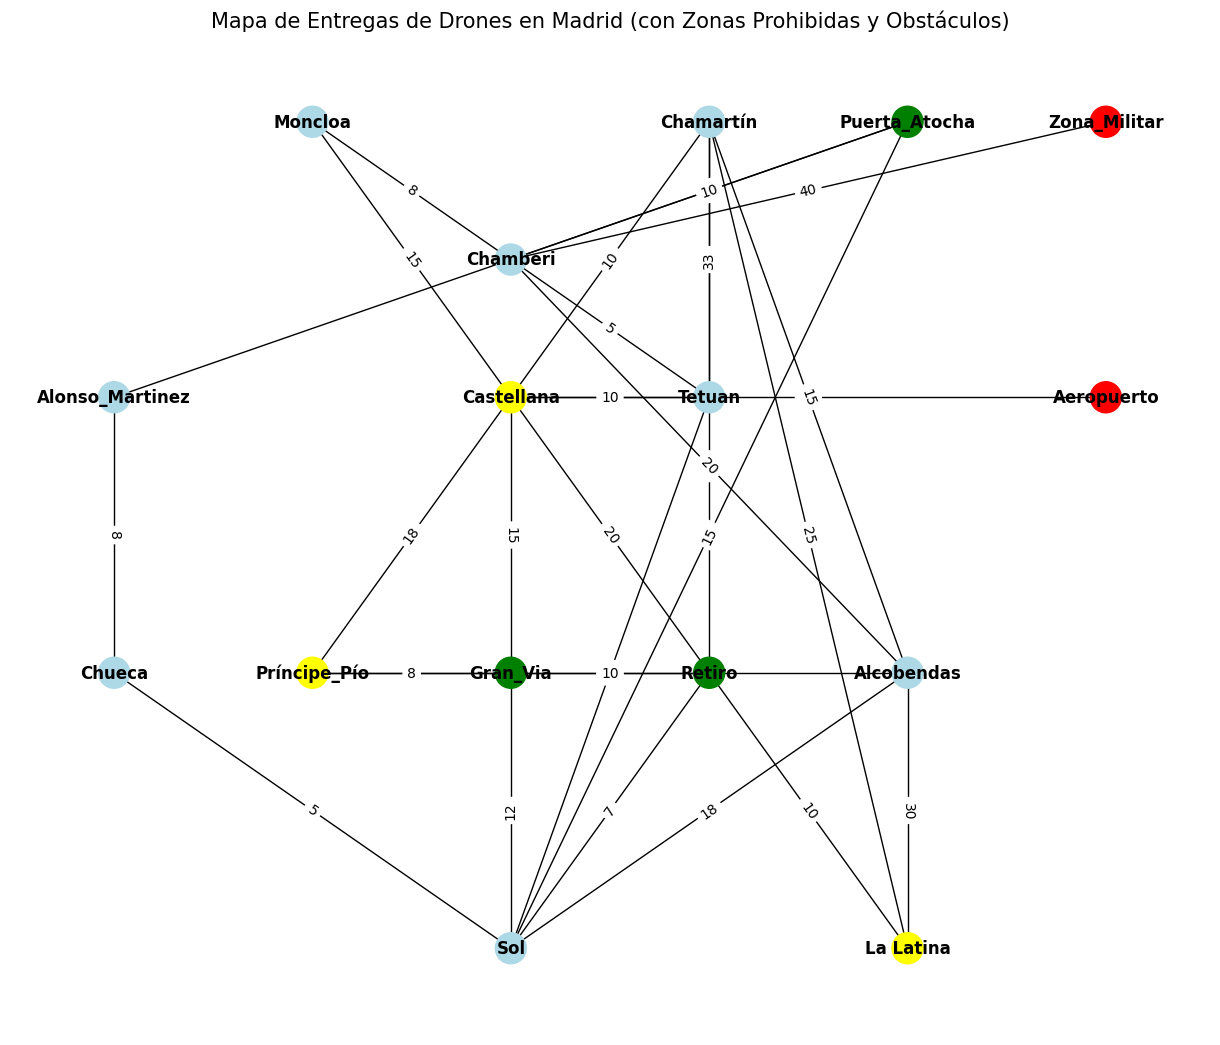

In [4]:
class MadridGraph:
    def __init__(self):
        self.graph = nx.Graph()  # Grafo no dirigido
        self.add_nodes_and_edges()
        # Zonas prohibidas (nombres de nodos)
        self.prohibited_zones = ['Aeropuerto', 'Zona_Militar']
        # Condiciones climáticas que ralentizan el dron
        self.weather_conditions = ['viento', 'lluvia']
        self.weather_conditions_zones = ['Castellana','La Latina', 'Príncipe_Pío']
        # Obstáculos
        self.obstacles = ['Retiro', 'Gran_Via', 'Puerta_Atocha']

    def add_nodes_and_edges(self):
      # Nodo (nombre del lugar) y aristas (con distancias en minutos)
      self.graph.add_weighted_edges_from([
          ('Castellana', 'Tetuan', 10),
          ('Castellana', 'Moncloa', 15),
          ('Tetuan', 'Chamberi', 5),
          ('Moncloa', 'Chamberi', 8),
          ('Chamberi', 'Alcobendas', 20),
          ('Castellana', 'Aeropuerto', 40),
          ('Chamberi', 'Zona_Militar', 40),
          ('Castellana', 'Retiro', 20),
          ('Castellana', 'Chamartín', 10),
          ('Sol', 'Retiro', 7),
          ('Sol', 'Alcobendas', 18),
          ('Retiro', 'Chamartín', 13),
          ('Tetuan', 'Chamartín', 33),
          ('Alcobendas', 'Chamartín', 15),
          ('Sol', 'Tetuan', 14),
          ('Retiro', 'La Latina', 10),
          ('Chamartín', 'La Latina', 25),
          ('La Latina', 'Alcobendas', 30),
          ('Sol', 'Puerta_Atocha', 15),
          ('Sol', 'Gran_Via', 12),
          ('Castellana', 'Gran_Via', 15),
          ('Gran_Via', 'Sol', 12),
          ('Retiro', 'Gran_Via', 10),
          ('Gran_Via', 'Príncipe_Pío', 8),
          ('Príncipe_Pío', 'Castellana', 18),
          ('Puerta_Atocha', 'Alonso_Martinez', 12),
          ('Chamberi', 'Puerta_Atocha', 10),
          ('Alonso_Martinez', 'Chueca', 8),
          ('Chueca', 'Sol', 5),
          ('Príncipe_Pío', 'Alcobendas', 22),

      ])

    def get_neighbors(self, node):
        return list(self.graph.neighbors(node))

    def get_distance(self, from_node, to_node):
        return self.graph[from_node][to_node]['weight']

    def get_weather_factor(self):
        return random.uniform(1.0, 1.5) if random.choice(self.weather_conditions) == 'viento' else 1.0

    def get_obstacle_factor(self):
        return random.uniform(1.0, 1.3) if random.choice(self.obstacles) == 'edificio_alto' else 1.0

    def is_prohibited_zone(self, node):
        return node in self.prohibited_zones

def draw_graph(graph):
    # Diccionario con las posiciones de cada nodo
    pos = {
        'Castellana': (0, 0),
        'Chamartín': (1, 1),
        'Sol': (0, -2),
        'Retiro': (1, -1),
        'Alcobendas': (2, -1),
        'Moncloa': (-1, 1),
        'Tetuan': (1, 0),
        'Chamberi': (0, 0.5),
        'Aeropuerto': (3, 0),
        'La Latina': (2, -2),
        'Zona_Militar': (3, 1),
        'Puerta_Atocha': (2, 1),
        'Gran_Via': (0, -1),
        'Príncipe_Pío': (-1, -1),
        'Alonso_Martinez': (-2, 0),
        'Chueca': (-2, -1),
    }

    # Colores para visualizar zonas prohibidas, con obstáculos, etc.
    node_colors = []
    for node in graph.graph.nodes():
        # Priorizar zonas prohibidas en rojo
        if node in graph.prohibited_zones:
            node_colors.append('red')
        # Luego verificar obstáculos en verde
        elif node in graph.obstacles:
            node_colors.append('green')
        # Luego verificar las zpnas con clima en amarillo
        elif node in graph.weather_conditions_zones:
            node_colors.append('yellow')
        # Nodos normales en azul claro
        else:
            node_colors.append('lightblue')

    # Dibujar el grafo
    plt.figure(figsize=(12, 10))
    nx.draw(graph.graph, pos, with_labels=True, node_size=500, node_color=node_colors, font_size=12, font_weight='bold')

    # Mostrar los pesos en las aristas
    edge_labels = nx.get_edge_attributes(graph.graph, 'weight')
    nx.draw_networkx_edge_labels(graph.graph, pos, edge_labels=edge_labels)

    # Título del grafo
    plt.title("Mapa de Entregas de Drones en Madrid (con Zonas Prohibidas y Obstáculos)", fontsize=15)

    # Mostrar el gráfico
    plt.show()

# Crear el grafo de Madrid
graph = MadridGraph()

# Mostrar el grafo
draw_graph(graph)


### **PARTE 4 -- Implementación de clases para la gestión de drones y entregas**

Esta celda introduce las clases **`Dron`** y **`SistemaDrones`**, diseñadas para gestionar las entregas de manera eficiente utilizando un sistema de drones.  

#### **1. Clase `Dron`**  
Modela un dron con los siguientes atributos y métodos:  
- **Atributos**:  
  - `id`: Identificador único del dron.  
  - `bateria`: Nivel de batería del dron (inicia en 100%).  
  - `ubicacion_actual`: Nodo donde se encuentra el dron (inicia en "Castellana").  
  - `capacidad_actual`: Capacidad ocupada del dron (máximo 5 kg).  
  - `pedidos`: Lista de pedidos asignados al dron.  
- **Métodos**:  
  - `puede_agregar_pedido`: Verifica si el dron puede aceptar un pedido según su peso.  
  - `agregar_pedido`: Añade un pedido a la lista y actualiza la capacidad ocupada.  

#### **2. Clase `SistemaDrones`**  
Gestiona una flota de drones y coordina las entregas:  
- **Atributos**:  
  - `graph`: Representación del mapa mediante un objeto de `MadridGraph`.  
  - `drones`: Lista de drones disponibles.  
  - `cola_pedidos`: Cola para almacenar los pedidos pendientes.  
  - `entregas_log`: Registro detallado de las operaciones realizadas por los drones.  
- **Métodos**:  
  - `calcular_ruta_optima`: Determina la ruta más eficiente entre dos nodos utilizando los algoritmos de Dijkstra y A*.  
  - `realizar_entrega`: Asigna pedidos a drones, calcula rutas óptimas, verifica restricciones (zonas prohibidas, batería), y registra las entregas realizadas.  
  - `agregar_pedido`: Agrega un pedido a la cola, especificando destino, peso, y tipo de fármaco.  

#### **3. Funcionalidad principal**  
- Los drones priorizan rutas rápidas, respetan restricciones (zonas prohibidas y batería) y actualizan su capacidad tras completar entregas.  
- Las rutas óptimas incluyen factores dinámicos como clima y obstáculos.  
- Los logs detallados ayudan a rastrear cada entrega, desde la asignación hasta la finalización.


In [5]:

class Dron:
    def __init__(self, id):
        self.id = id
        self.bateria = 100.0
        self.ubicacion_actual = "Castellana"
        self.capacidad_actual = 0
        self.pedidos = []

    def puede_agregar_pedido(self, peso):
        return self.capacidad_actual + peso <= 5

    def agregar_pedido(self, pedido, farmaco = 'Any'):
        self.pedidos.append(pedido)
        self.capacidad_actual += pedido['peso']

class SistemaDrones:
    def __init__(self, graph):
        self.graph = graph
        self.drones = [Dron(i) for i in range(3)]
        self.cola_pedidos = queue.Queue()
        self.entregas_log = []

    def calcular_ruta_optima(self, origen, destino):
      try:
          # Calcular ruta con Dijkstra
          ruta_dijkstra = nx.dijkstra_path(self.graph.graph, origen, destino, weight='weight')
          tiempo_dijkstra = sum(self.graph.get_distance(ruta_dijkstra[i], ruta_dijkstra[i+1]) for i in range(len(ruta_dijkstra)-1))

          # Calcular ruta con A*
          ruta_astar = nx.astar_path(self.graph.graph, origen, destino, weight='weight')
          tiempo_astar = sum(self.graph.get_distance(ruta_astar[i], ruta_astar[i+1]) for i in range(len(ruta_astar)-1))

          # Aplicar factores de clima y obstáculos
          tiempo_dijkstra *= self.graph.get_weather_factor()
          tiempo_dijkstra *= self.graph.get_obstacle_factor()

          tiempo_astar *= self.graph.get_weather_factor()
          tiempo_astar *= self.graph.get_obstacle_factor()

          # Seleccionar la ruta más rápida
          if tiempo_dijkstra <= tiempo_astar:
              return ruta_dijkstra, round(tiempo_dijkstra, 1), "Dijkstra"
          else:
              return ruta_astar, round(tiempo_astar, 1), "A*"

      except nx.NetworkXNoPath:
          # Si no hay ruta, manejar el error
          raise ValueError(f"No se encontró ruta entre {origen} y {destino}")

    def realizar_entrega(self):
      self.entregas_log = []
      # Ordena los drones por su capacidad actual de carga, de menor a mayor
      drones_ordenados = sorted(self.drones, key=lambda x: x.capacidad_actual)

      for dron in drones_ordenados:
        # Mientras haya pedidos en la cola y la capacidad del dron sea menor que 5
          while not self.cola_pedidos.empty() and dron.capacidad_actual < 5:
            # Obtiene el siguiente pedido de la cola
              pedido_candidato = self.cola_pedidos.get()

              # Verifica si el destino del pedido no está en una zona prohibida
              # y si el dron puede llevar el peso del pedido
              if (not self.graph.is_prohibited_zone(pedido_candidato['destino']) and
                  dron.puede_agregar_pedido(pedido_candidato['peso'])):
                  # Si es posible, agrega el pedido al dron y agrega el log
                  dron.agregar_pedido(pedido_candidato)
                  log_entry = f"Dron {dron.id} recogió pedido de {pedido_candidato['farmaco']} ({pedido_candidato['peso']}kg) a {pedido_candidato['destino']}"
                  self.entregas_log.append(log_entry)
              else:
                  self.cola_pedidos.put(pedido_candidato)
                  break
          # Si el dron tiene pedidos, se procede con la entrega
          if dron.pedidos:
              for pedido in dron.pedidos:
                # Calcula la ruta óptima para entregar el pedido
                  ruta, tiempo, algoritmo = self.calcular_ruta_optima(dron.ubicacion_actual, pedido['destino'])

                  if dron.bateria - tiempo < 10:
                    # Si la batería es insuficiente, se registra el problema y se detiene el proceso
                      log_entry = f"Dron {dron.id} no puede continuar, batería baja."
                      self.entregas_log.append(log_entry)
                      break

                  # Log de ruta de ida
                  self.entregas_log.append(f"Ruta del Dron {dron.id}:")
                  for nodo in ruta[:-1]:
                      self.entregas_log.append(f"  Pasando por: {nodo}")

                  # Actualiza la ubicación del dron a su destino, reduce su bateria y capacidad actual
                  dron.ubicacion_actual = pedido['destino']
                  dron.bateria = round(dron.bateria - tiempo, 1)
                  dron.capacidad_actual -= pedido['peso']

                  # Logs de entrega
                  entrega_logs = [
                      f"Pedido de {pedido['farmaco']} ({pedido_candidato['peso']}kg) entregado en {pedido['destino']}",
                      f"Tiempo de entrega: {tiempo} minutos",
                      f"Algoritmo de ruta seleccionado: {algoritmo}",
                      f"Batería restante: {dron.bateria}%",
                      f"Capacidad actual del dron: {dron.capacidad_actual} kg"
                  ]
                  self.entregas_log.extend(entrega_logs)

              # Volver a Castellana después de entregar todos los pedidos
              if dron.bateria > 10:
                  ruta_vuelta, tiempo_vuelta, _ = self.calcular_ruta_optima(dron.ubicacion_actual, "Castellana")

                  # Log de ruta de vuelta
                  self.entregas_log.append(f"Ruta de vuelta del Dron {dron.id}:")
                  for nodo in ruta_vuelta[:-1]:
                      self.entregas_log.append(f"  Pasando por: {nodo}")

                  dron.ubicacion_actual = "Castellana"
                  dron.bateria = round(dron.bateria - tiempo_vuelta, 1)
                  dron.bateria = 100.0

                  vuelta_logs = [
                      f"Dron {dron.id} ha regresado a Castellana.",
                      "Batería recargada"
                  ]
                  self.entregas_log.extend(vuelta_logs)

              # Limpiar pedidos después de la entrega
              dron.pedidos = []
              dron.capacidad_actual = 0

      return self.entregas_log

    def agregar_pedido(self, destino, peso, farmaco):
        self.cola_pedidos.put({
            'destino': destino,
            'peso': peso,
            'farmaco': farmaco
        })
        return f"Pedido agregado: {peso} kg de {farmaco} a {destino}"



### **PARTE 5 -- Configuración de Flask e inicialización del sistema de drones**

En esta celda se configuran los componentes básicos para la aplicación web utilizando **Flask** y se inicializan las estructuras principales:  

#### **1. Configuración de Flask**  
- Se crea una instancia de **`Flask`**, la cual servirá como base para la aplicación web que gestionará las operaciones del sistema de drones.

#### **2. Inicialización del sistema de drones**  
- Se crea un objeto **`MadridGraph`** para representar el mapa de la ciudad con nodos, aristas y condiciones especiales (zonas prohibidas, obstáculos, etc.).  
- Se instancia el sistema de drones a través de la clase **`SistemaDrones`**, utilizando el grafo de Madrid como base para el cálculo de rutas y gestión de entregas.  

Este paso prepara la infraestructura necesaria para que Flask interactúe con el sistema de drones.


In [6]:
# Configuración de Flask
app = Flask(__name__)

# Inicializar sistema de drones
graph = MadridGraph()
sistema = SistemaDrones(graph)

### **PARTE 6 -- Rutas de la aplicación web**

En esta parte se definen las rutas de la aplicación Flask, que permiten interactuar con la interfaz y los servicios del sistema de drones. Las principales rutas incluyen:

#### **1. Ruta principal (`/`)**
- Genera una página web que permite a los usuarios seleccionar:
  - **Destino**: Filtrado para excluir zonas prohibidas.
  - **Fármaco**: Una lista de medicamentos predefinida.
  - **Peso**: Un rango de opciones (1-3 kg).
- Implementa un diseño atractivo con HTML y CSS, utilizando un formulario que se envía mediante `POST` a la ruta `/realizar_pedido`.
- Botón adicional para iniciar todas las entregas (`GET` hacia `/realizar_entregas`).

#### **2. Ruta para realizar pedidos (`/realizar_pedido`)**
- **Método HTTP**: `POST`.
- Obtiene los datos del formulario enviado:
  - `destino`, `peso`, y `fármaco`.
- Utiliza el sistema de drones para agregar un pedido mediante el método **`agregar_pedido`**.
- Devuelve una página de confirmación del pedido con un mensaje que refleja el resultado del sistema.

#### **3. Ruta para realizar entregas (`/realizar_entregas`)**
- **Método HTTP**: `GET`.
- Llama al método **`realizar_entrega`** del sistema de drones para procesar y completar los pedidos.
- Muestra un registro detallado de las entregas realizadas, con diseño responsive y una estructura visual que facilita la comprensión de los datos.

#### **Estilo y diseño**
- Se utiliza HTML con **plantillas dinámicas** de Jinja2 para generar contenido (listas desplegables y registros).
- Se incluye CSS para:
  - Diseños modernos y minimalistas.
  - Experiencia de usuario responsiva y atractiva.
  - Efectos interactivos como hover y animaciones para botones y contenedores.

Esta sección combina la funcionalidad de Flask con un diseño front-end para proporcionar una interfaz de usuario funcional y estéticamente agradable.


In [7]:
# Rutas de la aplicación web
@app.route('/')
def index():
    destinos = [nodo for nodo in graph.graph.nodes() if nodo not in graph.prohibited_zones]
    farmacos = ["Paracetamol", "Ibuprofeno", "Omeprazol", "Amoxicilina", "Lorazepam"]
    pesos = [1, 2, 3]

    template = """
    <!DOCTYPE html>
    <html lang="es">
    <head>
        <meta charset="UTF-8">
        <title>PharmaDrone Madrid</title>
        <style>
            @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600&display=swap');

            * {
                margin: 0;
                padding: 0;
                box-sizing: border-box;
            }

            body {
                font-family: 'Inter', sans-serif;
                background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
                display: flex;
                justify-content: center;
                align-items: center;
                min-height: 100vh;
                margin: 0;
                padding: 20px;
            }

            .container {
                background: white;
                border-radius: 20px;
                box-shadow: 0 20px 40px rgba(0,0,0,0.1);
                width: 450px;
                padding: 40px;
                text-align: center;
                position: relative;
                overflow: hidden;
            }

            .container::before {
                content: '';
                position: absolute;
                top: 0;
                left: 0;
                width: 100%;
                height: 5px;
                background: linear-gradient(to right, #3498db, #2ecc71);
            }

            .logo {
                display: flex;
                align-items: center;
                justify-content: center;
                margin-bottom: 25px;
            }

            .logo svg {
                width: 50px;
                height: 50px;
                color: #3498db;
                margin-right: 15px;
            }

            .logo h1 {
                color: #2c3e50;
                font-size: 1.8em;
                font-weight: 600;
            }

            .form-group {
                margin-bottom: 20px;
            }

            .custom-select {
                width: 100%;
                padding: 12px 15px;
                border: 2px solid #e0e0e0;
                border-radius: 8px;
                font-size: 16px;
                transition: all 0.3s ease;
                appearance: none;
                background: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' width='12' height='12' viewBox='0 0 12 12'%3E%3Cpath d='M1 4l5 5 5-5' fill='none' stroke='%23999' stroke-width='1.5'/%3E%3C/svg%3E") no-repeat right 15px center;
                background-size: 12px;
            }

            .custom-select:focus {
                outline: none;
                border-color: #3498db;
                box-shadow: 0 0 0 2px rgba(52, 152, 219, 0.2);
            }

            .btn {
                display: inline-block;
                width: 100%;
                padding: 14px;
                background: #3498db;
                color: white;
                border: none;
                border-radius: 8px;
                font-weight: 600;
                text-transform: uppercase;
                letter-spacing: 1px;
                cursor: pointer;
                transition: all 0.3s ease;
                margin-top: 10px;
            }

            .btn:hover {
                background: #2980b9;
                transform: translateY(-3px);
                box-shadow: 0 4px 10px rgba(0,0,0,0.1);
            }

            .btn-secondary {
                background: #2ecc71;
            }

            .btn-secondary:hover {
                background: #27ae60;
            }
        </style>
    </head>
    <body>
        <div class="container">
            <div class="logo">
                <svg xmlns="http://www.w3.org/2000/svg" fill="none" viewBox="0 0 24 24" stroke="currentColor">
                    <path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M12 19l9 2-9-2zm0 0v-8m0 0L3 9l9 2m0 0l6-2-6 2zm0 0v8m0-8L3 9l9 2" />
                </svg>
                <h1>PharmaDrone Madrid</h1>
            </div>

            <form action="/realizar_pedido" method="post">
                <div class="form-group">
                    <select name="destino" class="custom-select" required>
                        <option value="">Seleccionar Destino</option>
                        {% for destino in destinos %}
                        <option value="{{ destino }}">{{ destino }}</option>
                        {% endfor %}
                    </select>
                </div>
                <div class="form-group">
                    <select name="farmaco" class="custom-select" required>
                        <option value="">Seleccionar Farmaco</option>
                        {% for farmaco in farmacos %}
                        <option value="{{ farmaco }}">{{ farmaco }}</option>
                        {% endfor %}
                    </select>
                </div>
                <div class="form-group">
                    <select name="peso" class="custom-select" required>
                        <option value="">Seleccionar Peso</option>
                        {% for peso in pesos %}
                        <option value="{{ peso }}">{{ peso }} kg</option>
                        {% endfor %}
                    </select>
                </div>
                <button type="submit" class="btn">Realizar Pedido</button>
            </form>

            <form action="/realizar_entregas" method="get">
                <button type="submit" class="btn btn-secondary">Realizar Entregas</button>
            </form>
        </div>
    </body>
    </html>
    """
    return render_template_string(template, destinos=destinos,farmacos=farmacos, pesos=pesos)

@app.route('/realizar_pedido', methods=['POST'])
def realizar_pedido():
    destino = request.form['destino']
    peso = int(request.form['peso'])
    farmaco = request.form['farmaco']
    resultado = sistema.agregar_pedido(destino, peso, farmaco)

    template = """
    <!DOCTYPE html>
    <html lang="es">
    <head>
        <meta charset="UTF-8">
        <title>PharmaDrone - Resultado del Pedido</title>
        <style>
            @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600&display=swap');

            body {
                font-family: 'Inter', sans-serif;
                background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
                display: flex;
                justify-content: center;
                align-items: center;
                min-height: 100vh;
                margin: 0;
                padding: 20px;
                box-sizing: border-box;
            }
            .result-container {
                background: white;
                border-radius: 15px;
                box-shadow: 0 15px 35px rgba(50,50,93,.1), 0 5px 15px rgba(0,0,0,.07);
                width: 400px;
                padding: 40px;
                text-align: center;
                position: relative;
                overflow: hidden;
            }
            .result-container::before {
                content: '';
                position: absolute;
                top: 0;
                left: 0;
                width: 100%;
                height: 5px;
                background: linear-gradient(to right, #3498db, #2ecc71);
            }
            .result-icon {
                width: 80px;
                height: 80px;
                background: #e9f5fe;
                border-radius: 50%;
                display: flex;
                justify-content: center;
                align-items: center;
                margin: 0 auto 20px;
                animation: pulse 2s infinite;
            }
            .result-icon svg {
                width: 40px;
                height: 40px;
                color: #3498db;
            }
            @keyframes pulse {
                0% { transform: scale(1); }
                50% { transform: scale(1.05); }
                100% { transform: scale(1); }
            }
            h2 {
                color: #2c3e50;
                margin-bottom: 15px;
                font-weight: 600;
            }
            .result-message {
                background: #f9fafb;
                padding: 15px;
                border-radius: 8px;
                margin-bottom: 20px;
                color: #6c757d;
                font-size: 0.95em;
                line-height: 1.6;
            }
            .return-button {
                display: inline-block;
                background: #3498db;
                color: white;
                padding: 12px 25px;
                text-decoration: none;
                border-radius: 6px;
                transition: all 0.3s ease;
                font-weight: 600;
                text-transform: uppercase;
                letter-spacing: 1px;
            }
            .return-button:hover {
                background: #2980b9;
                transform: translateY(-3px);
                box-shadow: 0 4px 10px rgba(0,0,0,0.1);
            }
        </style>
    </head>
    <body>
        <div class="result-container">
            <div class="result-icon">
                <svg xmlns="http://www.w3.org/2000/svg" fill="none" viewBox="0 0 24 24" stroke="currentColor">
                    <path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M9 12l2 2 4-4m6 2a9 9 0 11-18 0 9 9 0 0118 0z" />
                </svg>
            </div>
            <h2>Resultado del Pedido</h2>
            <div class="result-message">
                {{ mensaje }}
            </div>
            <a href="/" class="return-button">Volver al Inicio</a>
        </div>
    </body>
    </html>
    """
    return render_template_string(template, mensaje=resultado)

@app.route('/realizar_entregas', methods=['GET'])
def realizar_entregas():
    logs = sistema.realizar_entrega()

    template = """
      <!DOCTYPE html>
      <html lang="es">
      <head>
          <meta charset="UTF-8">
          <title>PharmaDrone - Entregas Realizadas</title>
          <style>
              @import url('https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600&display=swap');

              body {
                  font-family: 'Inter', sans-serif;
                  background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%);
                  display: flex;
                  justify-content: center;
                  align-items: center;
                  min-height: 100vh;
                  margin: 0;
                  padding: 20px;
                  box-sizing: border-box;
              }
              .delivery-container {
                  background: white;
                  border-radius: 15px;
                  box-shadow: 0 15px 35px rgba(50,50,93,.1), 0 5px 15px rgba(0,0,0,.07);
                  width: 500px;
                  max-height: 80vh;
                  overflow-y: auto;
                  padding: 30px;
                  position: relative;
              }
              .delivery-header {
                  display: flex;
                  align-items: center;
                  justify-content: space-between;
                  margin-bottom: 20px;
                  border-bottom: 2px solid #f0f2f5;
                  padding-bottom: 15px;
              }
              .delivery-header h2 {
                  margin: 0;
                  color: #2c3e50;
                  font-weight: 600;
                  display: flex;
                  align-items: center;
              }
              .delivery-header svg {
                  margin-right: 10px;
                  width: 30px;
                  height: 30px;
              }
              .delivery-logs {
                  display: flex;
                  flex-direction: column;
                  gap: 15px;
              }
              .log-entry {
                  background: #f9fafb;
                  border-left: 4px solid #3498db;
                  padding: 15px;
                  border-radius: 5px;
                  position: relative;
                  transition: all 0.3s ease;
              }
              .log-entry:hover {
                  transform: translateX(10px);
                  box-shadow: 0 5px 15px rgba(0,0,0,0.05);
              }
              .log-category {
                  font-weight: 600;
                  color: #2c3e50;
                  margin-bottom: 5px;
              }
              .log-details {
                  color: #6c757d;
                  font-size: 0.9em;
              }
              .return-button {
                  display: inline-block;
                  background: #3498db;
                  color: white;
                  padding: 10px 20px;
                  text-decoration: none;
                  border-radius: 5px;
                  margin-top: 20px;
                  transition: background 0.3s ease;
                  font-weight: 600;
              }
              .return-button:hover {
                  background: #2980b9;
              }
          </style>
      </head>
      <body>
          <div class="delivery-container">
              <div class="delivery-header">
                  <h2>
                      <svg xmlns="http://www.w3.org/2000/svg" fill="none" viewBox="0 0 24 24" stroke="currentColor">
                          <path stroke-linecap="round" stroke-linejoin="round" stroke-width="2" d="M9 12l2 2 4-4M7.835 4.697a3.42 3.42 0 001.946-.806 3.42 3.42 0 014.438 0 3.42 3.42 0 001.946.806 3.42 3.42 0 013.138 3.138 3.42 3.42 0 00.806 1.946 3.42 3.42 0 010 4.438 3.42 3.42 0 00-.806 1.946 3.42 3.42 0 01-3.138 3.138 3.42 3.42 0 00-1.946.806 3.42 3.42 0 01-4.438 0 3.42 3.42 0 00-1.946-.806 3.42 3.42 0 01-3.138-3.138 3.42 3.42 0 00-.806-1.946 3.42 3.42 0 010-4.438 3.42 3.42 0 00.806-1.946 3.42 3.42 0 013.138-3.138z" />
                      </svg>
                      Entregas Realizadas
                  </h2>
              </div>
              <div class="delivery-logs">
                  {% for log in logs %}
                      <div class="log-entry">
                          <div class="log-category">{{ log.split(':')[0] if ':' in log else log }}</div>
                          {% if ':' in log %}
                          <div class="log-details">{{ log.split(':', 1)[1] }}</div>
                          {% endif %}
                      </div>
                  {% endfor %}
              </div>
              <a href="/" class="return-button">Volver al Inicio</a>
          </div>
      </body>
      </html>
    """
    return render_template_string(template, logs=logs)



### **PARTE 7 -- Configuración de `ngrok` y ejecución de Flask**

En esta última sección del código se configura la herramienta **ngrok** para exponer el servidor Flask local a través de una URL pública, lo que facilita el acceso remoto a la aplicación durante el desarrollo y pruebas.

#### **1. Función para iniciar ngrok**
- **`start_ngrok()`**:
  - Desconecta cualquier túnel activo para evitar conflictos.
  - Conecta ngrok al puerto `5000`, donde la aplicación Flask está configurada para ejecutarse.
  - Imprime la URL pública generada por ngrok, que permite acceder a la aplicación desde internet.

#### **2. Ejecución de ngrok en un hilo separado**
- Se inicia la función `start_ngrok` en un **hilo independiente** usando el módulo `threading`:
  - Esto asegura que ngrok se ejecute paralelamente al servidor Flask, sin bloquear el flujo principal de la aplicación.
  - Permite que ambas herramientas funcionen de manera simultánea y eficiente.

#### **3. Ejecución de Flask**
- En el bloque `if __name__ == "__main__"`, se llama a `app.run` para iniciar el servidor Flask:
  - Se define el puerto como `5000`, que coincide con el configurado para ngrok.
  - Este bloque asegura que la aplicación Flask se ejecute solo cuando el script se ejecute directamente, y no cuando sea importado como un módulo.

#### **Beneficio de usar ngrok**
- **Acceso remoto**: ngrok proporciona una URL temporal para probar la aplicación desde dispositivos o ubicaciones externas, facilitando la colaboración y pruebas en tiempo real.
- **Simplicidad**: Configurar ngrok con Flask en un entorno local elimina la necesidad de configurar servidores externos o redes complejas durante el desarrollo.

Esta parte asegura que la aplicación esté accesible tanto en local como remotamente, completando la configuración del sistema de drones.


In [8]:
# Función para iniciar ngrok
def start_ngrok():
    for tunnel in ngrok.get_tunnels():
        ngrok.disconnect(tunnel.public_url)
    public_url = ngrok.connect(5000)
    print(f"Aplicación disponible en: {public_url}")

# Iniciar ngrok en un hilo separado
threading.Thread(target=start_ngrok).start()

# Ejecutar la aplicación Flask
if __name__ == "__main__":
    app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


Aplicación disponible en: NgrokTunnel: "https://925d-34-41-153-168.ngrok-free.app" -> "http://localhost:5000"


INFO:werkzeug:127.0.0.1 - - [14/Jan/2025 16:49:16] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jan/2025 16:49:17] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [14/Jan/2025 16:49:27] "POST /realizar_pedido HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jan/2025 16:49:33] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jan/2025 16:49:38] "POST /realizar_pedido HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jan/2025 16:49:38] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [14/Jan/2025 16:49:39] "GET /realizar_entregas HTTP/1.1" 200 -


### **Parte Opcional: Sistema de Drones Farmacéuticos sin Web**

Esta versión del sistema no involucra una interfaz web, y en su lugar, utiliza la consola para interactuar con el usuario. Permite gestionar drones, realizar entregas de pedidos, y simular rutas óptimas usando los algoritmos Dijkstra y A*.

#### **1. Clases principales**
- **Clase `Dron`:** Representa a un dron con propiedades como:
  - **`id`:** Identificador único del dron.
  - **`bateria`:** Nivel de batería del dron (inicia en 100%).
  - **`ubicacion_actual`:** Ubicación del dron (por defecto "Castellana").
  - **`capacidad_actual`:** Capacidad ocupada del dron en kilos.
  - **`pedidos`:** Lista de pedidos asignados al dron.

  Los drones tienen métodos para verificar si pueden agregar más peso, y para agregar un pedido con su peso.

- **Clase `SistemaDrones`:** Gestiona los drones y el proceso de entrega. Incluye:
  - **`calcular_ruta_optima`:** Calcula la mejor ruta entre un origen y un destino utilizando los algoritmos Dijkstra y A*, considerando también factores de clima y obstáculos.
  - **`realizar_entrega`:** Se encarga de realizar las entregas de los pedidos, asignando drones disponibles y gestionando sus baterías y capacidades.
  - **`agregar_pedido`:** Agrega un nuevo pedido a la cola de entrega, asignándolo al primer dron disponible que pueda cargar el peso del paquete.

#### **2. Funcionalidades**
- **Interacción con el usuario**: Un menú interactivo en la consola permite a los usuarios realizar varias acciones:
  1. **Visualizar Grafo de Rutas:** Muestra las rutas entre las ubicaciones disponibles.
  2. **Realizar Pedido:** Permite agregar un pedido especificando destino y peso.
  3. **Estado de Drones:** Muestra la información actual de cada dron (batería, ubicación, capacidad).
  4. **Realizar Entregas:** Ejecuta las entregas de todos los pedidos pendientes.
  5. **Salir:** Finaliza la ejecución del programa.

#### **3. Menú principal**
El menú presenta varias opciones para interactuar con el sistema. Los usuarios pueden:
  - Consultar el estado actual de los drones.
  - Realizar nuevos pedidos seleccionando destinos y pesos.
  - Iniciar el proceso de entrega, en el que los drones realizan entregas optimizando el uso de sus baterías y capacidades.

#### **4. Algoritmos de Ruta (Dijkstra y A*)**
Los algoritmos de ruta, **Dijkstra** y **A***, son utilizados para calcular las rutas más rápidas entre el origen y destino de cada entrega, teniendo en cuenta el clima y obstáculos en el entorno.

#### **5. Simulación de Entregas**
El sistema simula el proceso de entrega, asegurándose de que los drones no se sobrecarguen y gestionando la batería. Si un dron tiene suficiente batería para realizar el recorrido, la entrega se efectúa; en caso contrario, el dron no puede continuar y se muestra un mensaje de advertencia.

#### **6. Regreso a la Base (Castellana)**
Después de realizar las entregas, si el dron tiene suficiente batería, regresa a la base ("Castellana") y se recarga para estar listo para futuras entregas.

Este enfoque simplificado es útil para desarrollos rápidos y pruebas del sistema de gestión de drones sin necesidad de tener una interfaz web.

### **Ventajas**
- **Simulación sin Web:** Puede ser útil para pruebas iniciales o entornos donde no se necesita una interfaz gráfica.
- **Interactividad en consola:** El usuario puede interactuar fácilmente con el sistema a través de la línea de comandos.


In [9]:
class Dron:
    def __init__(self, id):
        self.id = id
        self.bateria = 100.0
        self.ubicacion_actual = "Castellana"
        self.capacidad_actual = 0
        self.pedidos = []  # Lista de pedidos para este dron

    def puede_agregar_pedido(self, peso):
        return self.capacidad_actual + peso <= 5

    def agregar_pedido(self, pedido):
        self.pedidos.append(pedido)
        self.capacidad_actual += pedido['peso']

class SistemaDrones:
    def __init__(self, graph):
        self.graph = graph
        self.drones = [Dron(i) for i in range(3)]
        self.cola_pedidos = queue.Queue()

    def calcular_ruta_optima(self, origen, destino):
        # Calcular rutas con Dijkstra y A*
        ruta_dijkstra = nx.dijkstra_path(self.graph.graph, origen, destino, weight='weight')
        tiempo_dijkstra = sum(self.graph.get_distance(ruta_dijkstra[i], ruta_dijkstra[i+1]) for i in range(len(ruta_dijkstra)-1))

        ruta_astar = nx.astar_path(self.graph.graph, origen, destino, weight='weight')
        tiempo_astar = sum(self.graph.get_distance(ruta_astar[i], ruta_astar[i+1]) for i in range(len(ruta_astar)-1))

        # Aplicar factores de clima y obstáculos
        tiempo_dijkstra *= self.graph.get_weather_factor()
        tiempo_dijkstra *= self.graph.get_obstacle_factor()

        tiempo_astar *= self.graph.get_weather_factor()
        tiempo_astar *= self.graph.get_obstacle_factor()

        # Seleccionar la ruta más rápida
        if tiempo_dijkstra <= tiempo_astar:
            return ruta_dijkstra, round(tiempo_dijkstra, 1), "Dijkstra"
        else:
            return ruta_astar, round(tiempo_astar, 1), "A*"

    def realizar_entrega(self):
        drones_ordenados = sorted(self.drones, key=lambda x: x.capacidad_actual)

        for dron in drones_ordenados:
            while not self.cola_pedidos.empty() and dron.capacidad_actual < 5:
                pedido_candidato = self.cola_pedidos.get()

                if (not self.graph.is_prohibited_zone(pedido_candidato['destino']) and
                    dron.puede_agregar_pedido(pedido_candidato['peso'])):
                    dron.agregar_pedido(pedido_candidato)
                    print(f"Dron {dron.id} recogió pedido de {pedido_candidato['peso']}kg a {pedido_candidato['destino']}")
                else:
                    self.cola_pedidos.put(pedido_candidato)
                    break

            if dron.pedidos:
                for pedido in dron.pedidos:
                    ruta, tiempo, algoritmo = self.calcular_ruta_optima(dron.ubicacion_actual, pedido['destino'])

                    if dron.bateria - tiempo < 10:
                        print(f"Dron {dron.id} no puede continuar, batería baja.")
                        break

                    print(f"Ruta del Dron {dron.id}:")
                    for nodo in ruta[:-1]:
                        print(f"  Pasando por: {nodo}")

                    dron.ubicacion_actual = pedido['destino']
                    dron.bateria = round(dron.bateria - tiempo, 1)
                    dron.capacidad_actual -= pedido['peso']

                    print(f"Pedido de {pedido['peso']}kg entregado en {pedido['destino']}")
                    print(f"Tiempo de entrega: {tiempo} minutos")
                    print(f"Algoritmo de ruta seleccionado: {algoritmo}")
                    print(f"Batería restante: {dron.bateria}%")
                    print(f"Capacidad actual del dron: {dron.capacidad_actual} kg")

                # Volver a Castellana después de entregar todos los pedidos
                if dron.bateria > 10:  # Verificar si hay suficiente batería para volver
                    ruta_vuelta, tiempo_vuelta, _ = self.calcular_ruta_optima(dron.ubicacion_actual, "Castellana")
                    print(f"Ruta de vuelta del Dron {dron.id}:")
                    for nodo in ruta_vuelta[:-1]:  # Excluir el último nodo (Castellana)
                        print(f"  Pasando por: {nodo}")
                    dron.ubicacion_actual = "Castellana"
                    dron.bateria = round(dron.bateria - tiempo_vuelta, 1)
                    dron.bateria = 100.0
                    print(f"Dron {dron.id} ha regresado a Castellana.")
                    print(f"Batería recargada ")

                # Limpiar pedidos después de la entrega
                dron.pedidos = []
                dron.capacidad_actual = 0

    def agregar_pedido(self, destino, peso):
        for dron in sorted(self.drones, key=lambda x: x.capacidad_actual):
            if dron.puede_agregar_pedido(peso):
                self.cola_pedidos.put({
                    'destino': destino,
                    'peso': peso
                })
                print(f"Pedido agregado: {peso} kg a {destino}")
                return True

        print("No hay drones disponibles para este pedido.")
        return False

def menu_principal():
    graph = MadridGraph()
    sistema = SistemaDrones(graph)

    while True:
        print("\n--- Sistema de Entrega de Drones Farmacéuticos ---")
        print("1. Visualizar Grafo de Rutas")
        print("2. Realizar Pedido")
        print("3. Estado de Drones")
        print("4. Realizar Entregas")
        print("5. Salir")

        opcion = input("Seleccione una opción: ")

        if opcion == '1':
            draw_graph(graph)
        elif opcion == '2':
            destinos = ["Tetuan", "Chamberi", "Alcobendas", "Sol", "Retiro", "Chamartín", "Moncloa", "La Latina", "Puerta_Atocha", "Gran_Via", "Príncipe_Pío", "Alonso_Martinez", "Chueca"]
            pesos = [1, 2, 3]

            print("\nDestinos disponibles:")
            for i, dest in enumerate(destinos, 1):
                print(f"{i}. {dest}")

            dest_idx = int(input("Seleccione destino: ")) - 1

            print("\nTamaños de paquete:")
            for i, peso in enumerate(pesos, 1):
                print(f"{i}. {peso} kg")

            peso_idx = int(input("Seleccione tamaño de paquete: ")) - 1

            sistema.agregar_pedido(destinos[dest_idx], pesos[peso_idx])

        elif opcion == '3':
            for dron in sistema.drones:
                print(f"Dron {dron.id}:")
                print(f"  Batería: {dron.bateria}%")
                print(f"  Ubicación: {dron.ubicacion_actual}")
                print(f"  Capacidad: {dron.capacidad_actual} kg")

        elif opcion == '4':
            sistema.realizar_entrega()

        elif opcion == '5':
            break
        else:
            print("Opción inválida")

if __name__ == "__main__":
    menu_principal()


--- Sistema de Entrega de Drones Farmacéuticos ---
1. Visualizar Grafo de Rutas
2. Realizar Pedido
3. Estado de Drones
4. Realizar Entregas
5. Salir

Destinos disponibles:
1. Tetuan
2. Chamberi
3. Alcobendas
4. Sol
5. Retiro
6. Chamartín
7. Moncloa
8. La Latina
9. Puerta_Atocha
10. Gran_Via
11. Príncipe_Pío
12. Alonso_Martinez
13. Chueca

Tamaños de paquete:
1. 1 kg
2. 2 kg
3. 3 kg
Pedido agregado: 1 kg a Tetuan

--- Sistema de Entrega de Drones Farmacéuticos ---
1. Visualizar Grafo de Rutas
2. Realizar Pedido
3. Estado de Drones
4. Realizar Entregas
5. Salir

Destinos disponibles:
1. Tetuan
2. Chamberi
3. Alcobendas
4. Sol
5. Retiro
6. Chamartín
7. Moncloa
8. La Latina
9. Puerta_Atocha
10. Gran_Via
11. Príncipe_Pío
12. Alonso_Martinez
13. Chueca

Tamaños de paquete:
1. 1 kg
2. 2 kg
3. 3 kg
Pedido agregado: 1 kg a Chueca

--- Sistema de Entrega de Drones Farmacéuticos ---
1. Visualizar Grafo de Rutas
2. Realizar Pedido
3. Estado de Drones
4. Realizar Entregas
5. Salir
Dron 0 recogió p

KeyboardInterrupt: Interrupted by user